In [14]:
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
data_url = "http://jse.amstat.org/v19n3/decock/AmesHousing.txt"
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
        'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv(data_url, sep="\t", usecols=columns)
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})
df = df.dropna(axis=0)
X = df[['Gr Liv Area']].values
y = df[['SalePrice']].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (2929, 1), y shape: (2929, 1)


In [ ]:
# min_samples=0.95 =>給整數就是抽幾個樣本；給 0~1 之間的浮點數則代表抽總樣本數的比例。
# 0.95 表示每輪隨機抽 95% 的資料來訓練 LinearRegression
# 書中的假設是這個資料集（Ames Housing）離群值不多，所以用大部分資料去擬合，模型會比較穩定、接近一般的最小平方解

# residual threshold設置成None是讓scikit-learn用預設規則threshold=MAD
ransac = RANSACRegressor(LinearRegression(), max_trials=100, min_samples=0.95, loss='absolute_error', residual_threshold=None, random_state=0)
ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"random_state random_state: int, RandomState instance, default=NoneThe generator used to initialize the centers.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99


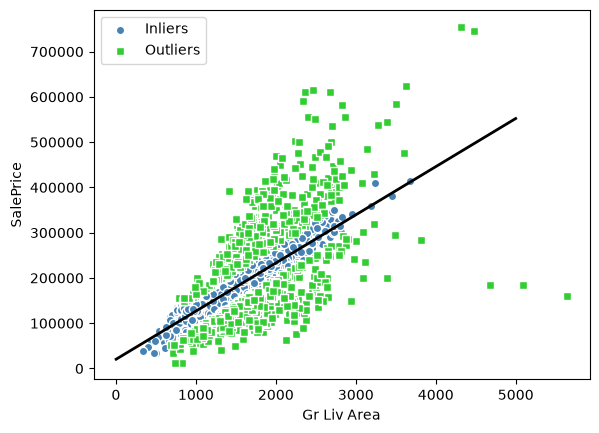

In [20]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3, 5000, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])

plt.scatter(X[inlier_mask], y[inlier_mask], c='steelblue', edgecolor='white', marker='o', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], c='limegreen', edgecolor='white', marker='s', label='Outliers')

plt.plot(line_X, line_y_ransac, color='black', lw=2)
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.legend(loc='upper left')

plt.show()

In [22]:
print(f"Slope {ransac.estimator_.coef_[0][0]:.3f}")
print(f"Intercept {ransac.estimator_.intercept_[0]:.3f}")

Slope 106.413
Intercept 20183.553
